<a href="https://colab.research.google.com/github/harshita-sl/renewable-energy-analysis/blob/main/renewable_energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()


#

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")

In [ ]:
import os

files = os.listdir("dataset_folder")
print(files)

['intermittent-renewables-production-france.csv']


In [ ]:
%matplotlib inline
import plotly.express as px

In [ ]:
df = pd.read_csv('dataset_folder/intermittent-renewables-production-france.csv')
df.head()
df = df.set_index('Date and Hour')
df.index =pd.to_datetime(df.index)

In [ ]:
df.info()
df.index


<class 'pandas.core.frame.DataFrame'>
Index: 59806 entries, 2020-07-22 20:00:00+02:00 to 2023-06-30 18:00:00+02:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        59806 non-null  object 
 1   StartHour   59806 non-null  object 
 2   EndHour     59806 non-null  object 
 3   Source      59806 non-null  object 
 4   Production  59804 non-null  float64
 5   dayOfYear   59806 non-null  int64  
 6   dayName     59806 non-null  object 
 7   monthName   59806 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 4.1+ MB


Index([2020-07-22 20:00:00+02:00, 2020-07-23 07:00:00+02:00,
       2020-07-23 16:00:00+02:00, 2020-07-23 19:00:00+02:00,
       2020-07-23 23:00:00+02:00, 2020-07-24 01:00:00+02:00,
       2020-07-24 04:00:00+02:00, 2020-07-24 05:00:00+02:00,
       2020-07-24 10:00:00+02:00, 2020-07-24 14:00:00+02:00,
       ...
       2023-06-29 15:00:00+02:00, 2023-06-29 21:00:00+02:00,
       2023-06-30 00:00:00+02:00, 2023-06-30 02:00:00+02:00,
       2023-06-30 04:00:00+02:00, 2023-06-30 06:00:00+02:00,
       2023-06-30 13:00:00+02:00, 2023-06-30 14:00:00+02:00,
       2023-06-30 16:00:00+02:00, 2023-06-30 18:00:00+02:00],
      dtype='object', name='Date and Hour', length=59806)

In [ ]:
pd.to_datetime(df.index, utc=True)

DatetimeIndex(['2020-07-22 18:00:00+00:00', '2020-07-23 05:00:00+00:00',
               '2020-07-23 14:00:00+00:00', '2020-07-23 17:00:00+00:00',
               '2020-07-23 21:00:00+00:00', '2020-07-23 23:00:00+00:00',
               '2020-07-24 02:00:00+00:00', '2020-07-24 03:00:00+00:00',
               '2020-07-24 08:00:00+00:00', '2020-07-24 12:00:00+00:00',
               ...
               '2023-06-29 13:00:00+00:00', '2023-06-29 19:00:00+00:00',
               '2023-06-29 22:00:00+00:00', '2023-06-30 00:00:00+00:00',
               '2023-06-30 02:00:00+00:00', '2023-06-30 04:00:00+00:00',
               '2023-06-30 11:00:00+00:00', '2023-06-30 12:00:00+00:00',
               '2023-06-30 14:00:00+00:00', '2023-06-30 16:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date and Hour', length=59806, freq=None)

In [ ]:
# Function to determine season based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Ensure the index is a DatetimeIndex
df.index = pd.to_datetime(df.index, utc=True)

# Create the 'Season' column if it doesn't exist
# This check prevents errors if the cell is run multiple times
if 'Season' not in df.columns:
    df['Season'] = df.index.month.map(get_season)

count_month = df['Season'].value_counts()
print(count_month)
df.head()

Season
Spring    16182
Winter    15840
Summer    14684
Fall      13100
Name: count, dtype: int64


,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName,Season
Date and Hour,,,,,,,,,
2020-07-22 18:00:00+00:00,2020-07-22,20:00:00,21:00:00,Solar,244.0,204,Wednesday,July,Summer
2020-07-23 05:00:00+00:00,2020-07-23,07:00:00,08:00:00,Solar,223.0,205,Thursday,July,Summer
2020-07-23 14:00:00+00:00,2020-07-23,16:00:00,17:00:00,Solar,2517.0,205,Thursday,July,Summer
2020-07-23 17:00:00+00:00,2020-07-23,19:00:00,20:00:00,Solar,658.0,205,Thursday,July,Summer
2020-07-23 21:00:00+00:00,2020-07-23,23:00:00,24:00:00,Solar,0.0,205,Thursday,July,Summer


In [ ]:
grouped_season = df.groupby('Season')['temperature_2m'].sum()
print(grouped_season)

KeyError: 'Column not found: temperature_2m'

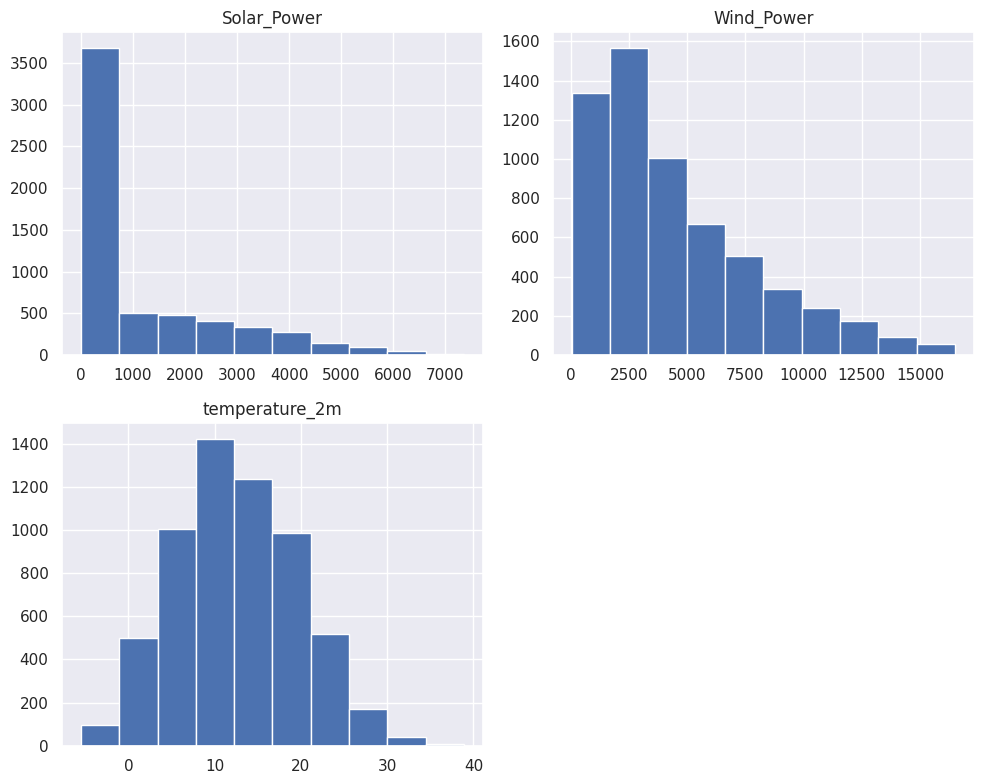

In [ ]:
df[['Solar_Power', 'Wind_Power', 'temperature_2m']].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
df.duplicated().sum()
data = df

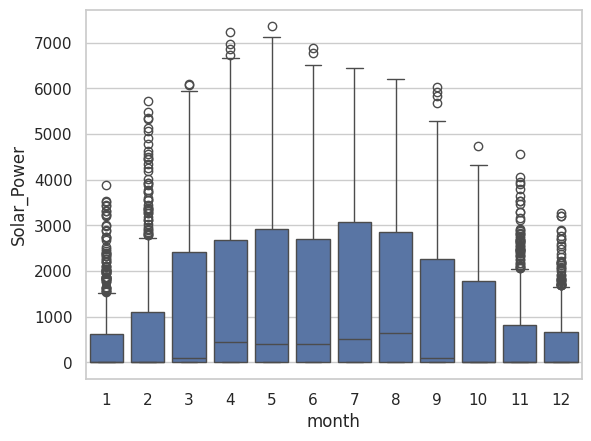

In [ ]:
sns.set(style= "whitegrid")
sns.boxplot(x='month', y='Solar_Power',data=df)
plt.show()

In [ ]:
fig = px.scatter(df,
                 x='Solar_Power',
                 y='Wind_Power',
                 color='temperature_2m', # Color points based on temperature
                 hover_data=['Season', 'month'], # Show season and month on hover
                 title='Solar Power vs Wind Power colored by Temperature')
fig.show()

In [ ]:
df_season_sum = df.groupby('Season')[['Solar_Power', 'Wind_Power']].sum().reset_index()
fig = px.bar(df_season_sum,
             x='Season',
             y=['Solar_Power', 'Wind_Power'], # Stacked bars
             title='Total Solar and Wind Power by Season')
fig.show()

In [ ]:
sns.set(style='darkgrid')

In [ ]:
fig = px.density_contour(df, x="cloudcover", y="Solar_Power", color="Season",
                         title="☁️ Solar Power vs Cloud Cover - Season Influence",
                         marginal_x="histogram", marginal_y="histogram")
fig.show()

<Figure size 1200x800 with 0 Axes>

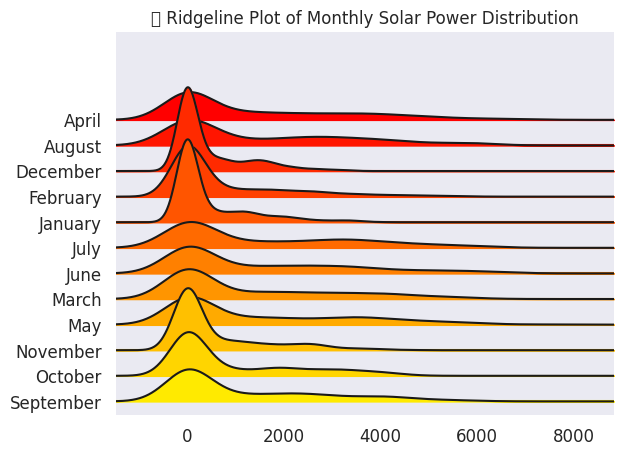

In [ ]:
!pip install joypy
import joypy
from matplotlib import cm
plt.figure(figsize=(12, 8))
joypy.joyplot(df, by="month_name", column="Solar_Power", colormap=cm.autumn,
              title="🌅 Ridgeline Plot of Monthly Solar Power Distribution")
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(df,
                    x='temperature_2m',
                    y='windspeed_10m',
                    z='Solar_Power',
                    color='hour',
                    size='shortwave_radiation',
                    hover_data=['month_name', 'cloudcover'],
                    title="Solar Power vs Temperature & Wind Speed",
                    labels={
                        "temperature_2m": "Temperature (°C)",
                        "windspeed_10m": "Wind Speed (m/s)",
                        "Solar_Power": "Solar Power Output",
                        "hour": "Hour of Day"
                    })

fig.update_layout(scene=dict(
                    xaxis_title='Temperature',
                    yaxis_title='Wind Speed',
                    zaxis_title='Solar Power'),
                    margin=dict(l=0, r=0, b=0, t=30))
fig.show()

In [ ]:
fig = px.parallel_coordinates(df,
                             color="hour",
                             dimensions=['Solar_Power', 'Wind_Power',
                                       'temperature_2m', 'windspeed_10m',
                                       'shortwave_radiation', 'cloudcover'],
                             color_continuous_scale=px.colors.diverging.Tealrose,
                             title="Parallel Coordinates of Energy and Weather Factors")
fig.show()

In [ ]:
# Select only numeric columns for the mean calculation
seasonal_avg = df.groupby('Season')[['Solar_Power', 'Wind_Power', 'temperature_2m', 'windspeed_10m', 'shortwave_radiation', 'cloudcover', 'hour']].mean().reset_index()

fig = px.line_polar(seasonal_avg,
                    r='Solar_Power',
                    theta='Season', # Changed theta to 'dayofyear' as groupby was on this column
                    line_close=True,
                    color_discrete_sequence=['#FFA15A'],
                    title="Seasonal Solar Power Patterns",
                    template="plotly_dark")

fig.update_traces(fill='toself')
fig.update_layout(polar=dict(radialaxis=dict(visible=True)),
                  showlegend=False)
fig.show()

In [ ]:
# Select only numeric columns for the mean calculation
seasonal_avg = df.groupby('Season')[['Solar_Power', 'Wind_Power', 'temperature_2m', 'windspeed_10m', 'shortwave_radiation', 'cloudcover', 'hour']].mean().reset_index()

fig = px.line_polar(seasonal_avg,
                    r='Wind_Power',
                    theta='Season', # Changed theta to 'dayofyear' as groupby was on this column
                    line_close=True,
                    color_discrete_sequence=['#FBA118'],
                    title="Seasonal Wind Power Patterns",
                    template="plotly_dark")

fig.update_traces(fill='toself')
fig.update_layout(polar=dict(radialaxis=dict(visible=True)),
                  showlegend=False)
fig.show()

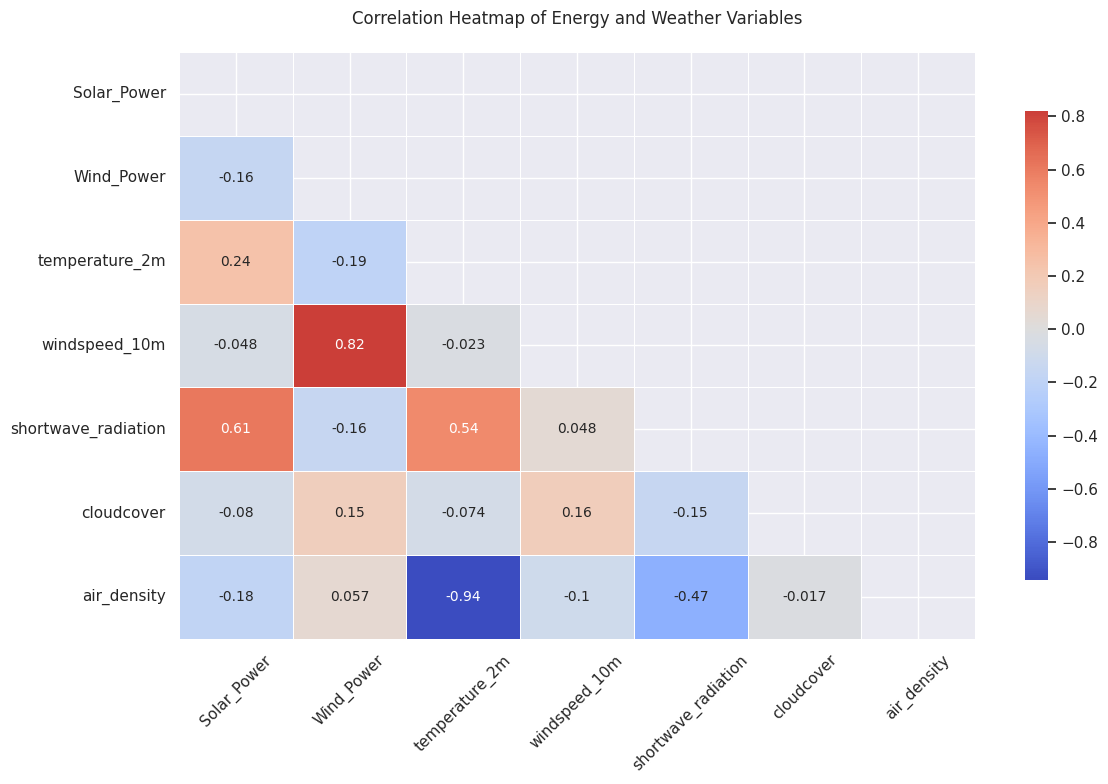

In [ ]:
plt.figure(figsize=(12, 8))
corr = df[['Solar_Power', 'Wind_Power', 'temperature_2m',
           'windspeed_10m', 'shortwave_radiation',
           'cloudcover', 'air_density']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            center=0,
            linewidths=.5,
            annot_kws={"size": 10},
            cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Energy and Weather Variables", pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

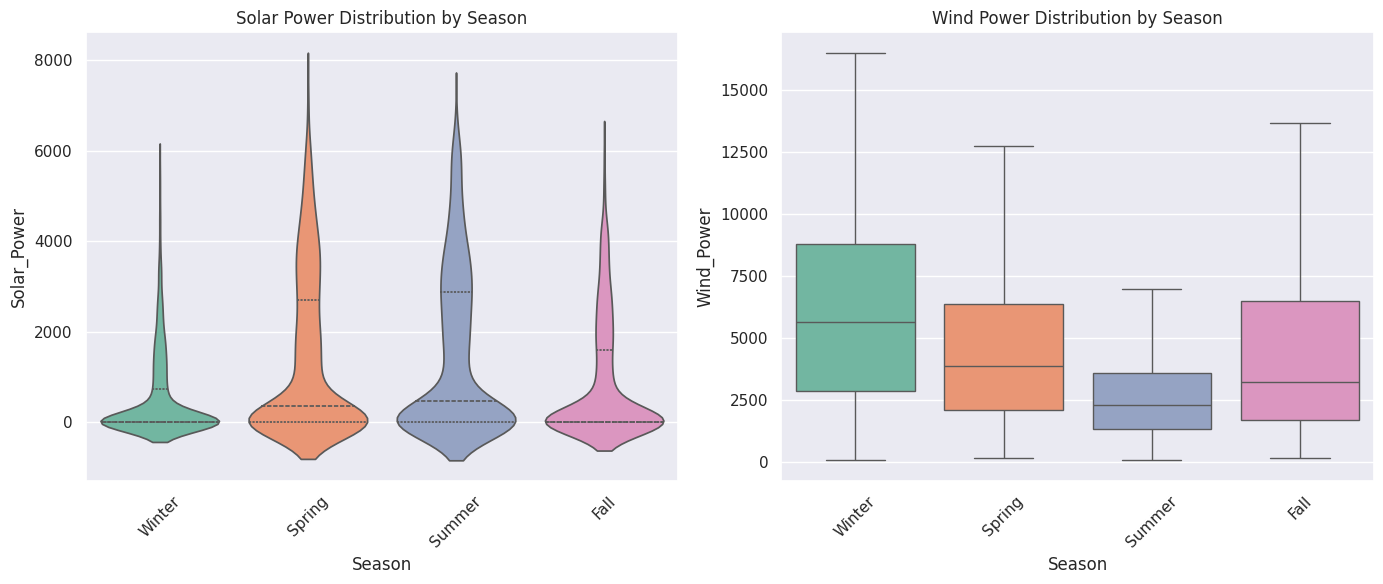

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x='Season', y='Solar_Power', data=df,
               palette='Set2', inner='quartile')
plt.title("Solar Power Distribution by Season")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(x='Season', y='Wind_Power', data=df,
            palette='Set2', showfliers=False)
plt.title("Wind Power Distribution by Season")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Define the correct month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert month_name to categorical with proper ordering
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

# Now create the sunburst chart
fig = px.sunburst(df,
                  path=['month_name', 'hour'],
                  values='Solar_Power',
                  color='temperature_2m',
                  color_continuous_scale='thermal',
                  title="Solar Power by Month and Hour (Ordered)")

fig.update_layout(margin=dict(t=30, l=0, r=0, b=0))
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Assuming df is your DataFrame
# Let's create an exaggerated version focusing on key relationships
exaggerated_df = df.copy()

# Apply exaggeration factors to highlight important relationships
exaggerated_df['Solar_Exaggerated'] = df['Solar_Power'] * (1 + df['shortwave_radiation']/df['shortwave_radiation'].max())
exaggerated_df['Wind_Exaggerated'] = df['Wind_Power'] * (1 + df['windspeed_10m']/df['windspeed_10m'].max())
exaggerated_df['Temp_Effect'] = df['temperature_2m'] * (1 - df['cloudcover']/100)  # Temp appears higher when less clouds

fig = px.scatter_3d(
    exaggerated_df,
    x='Temp_Effect',
    y='Wind_Exaggerated',
    z='Solar_Exaggerated',
    color='hour',
    size='air_density',  # Size by air density (affects both energy types)
    hover_data=['month_name', 'Season'],
    title="<b>Exaggerated 3D Energy Production Landscape</b><br>Size=Air Density, Color=Hour of Day",
    labels={
        'Temp_Effect': 'Temperature Effect (℃)',
        'Wind_Exaggerated': 'Wind Power Potential',
        'Solar_Exaggerated': 'Solar Power Potential',
        'hour': 'Hour of Day'
    },
    color_continuous_scale='jet',
    height=800
)

# Enhance 3D effect and exaggerate perspective
fig.update_layout(
    scene=dict(
        xaxis=dict(title='Temperature Effect<br>(adjusted for cloud cover)'),
        yaxis=dict(title='Wind Potential<br>(speed amplified)'),
        zaxis=dict(title='Solar Potential<br>(radiation amplified)'),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.6)  # Exaggerated perspective
        )
    ),
    coloraxis_colorbar=dict(title='Hour'),
    margin=dict(l=0, r=0, b=0, t=100)
)

# Add annotations to highlight key insights
fig.add_annotation(
    x=0.05, y=0.95, xref='paper', yref='paper',
    text="<b>Key Exaggerations:</b><br>• Solar scaled with radiation<br>• Wind scaled with speed<br>• Temp adjusted for clouds",
    showarrow=False,
    bgcolor='white',
    bordercolor='black'
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import numpy as np
from scipy.interpolate import griddata

# Create grid coordinates (assuming you have latitude/longitude - if not, we'll use time dimensions)
# For demonstration, I'll use dayofyear vs hour as our "map" coordinates
x = df['dayofyear'].values
y = df['hour'].values
z_solar = df['Solar_Power'].values
z_wind = df['Wind_Power'].values

# Create grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 24)
xi, yi = np.meshgrid(xi, yi)

# Interpolate z values
zi_solar = griddata((x, y), z_solar, (xi, yi), method='cubic')
zi_wind = griddata((x, y), z_wind, (xi, yi), method='cubic')

# Create exaggerated combined landscape (adjust weights to emphasize what matters)
zi_combined = 1.5*zi_solar + 0.8*zi_wind - 0.3*df['temperature_2m'].mean()

# Create the 3D surface map
fig = go.Figure(go.Surface(
    x=xi,
    y=yi,
    z=zi_combined,
    colorscale='Electric',
    contours_z=dict(
        show=True,
        usecolormap=True,
        highlightcolor="limegreen",
        project_z=True
    ),
    hovertemplate=
    "<b>Day %{x:.0f}</b><br>" +
    "Hour: %{y:.0f}<br>" +
    "Energy Potential: %{z:.1f}<extra></extra>"
))

# Add styling
fig.update_layout(
    title='<b>Exaggerated Energy Potential Landscape</b><br>(Solar + Wind - Temperature Effect)',
    scene=dict(
        xaxis_title='Day of Year',
        yaxis_title='Hour of Day',
        zaxis_title='Energy Potential',
        zaxis=dict(range=[0, zi_combined.max()*1.2]),
        camera=dict(
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=-0.2),
            eye=dict(x=1.5, y=1.5, z=0.8)
        ),
        aspectratio=dict(x=2, y=1, z=0.8)
    ),
    margin=dict(l=0, r=0, b=80, t=100),
    height=800
)

# Add contour lines on the "ground"
fig.update_traces(
    contours_z=dict(
        show=True,
        usecolormap=True,
        highlightcolor="limegreen",
        project_z=True
    ),
    showscale=True
)

# Add a plane at z=0 for reference
fig.add_trace(go.Surface(
    x=xi,
    y=yi,
    z=np.zeros_like(zi_combined),
    colorscale=[[0, 'rgba(0,0,0,0.2)'], [1, 'rgba(0,0,0,0.2)']],
    showscale=False,
    hoverinfo='skip'
))

fig.show()